# 0. 영화 추천 시스템

영화 추천 시스템을 만들어보자.

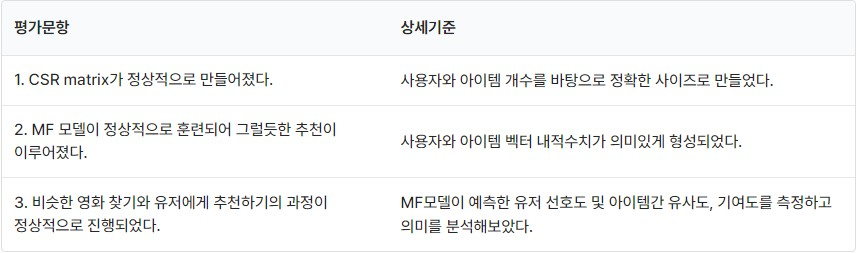

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

from implicit.als import AlternatingLeastSquares

# implicit 라이브러리에서 권장하고 있는 부분입니다. 학습 내용과는 무관합니다.
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['KMP_DUPLICATE_LIB_OK']='True'
os.environ['MKL_NUM_THREADS']='1'

# 1. 데이터 준비와 전처리하기

영화에 대한 유저별 평점이 들어있는 Movielens 1M Dataset 데이터를 이용한다.

https://grouplens.org/datasets/movielens/1m/

In [2]:
ratings_file_path = os.getenv('HOME') + '/aiffel/recommendata_iu/data/ml-1m/ratings.dat'
data_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
data = pd.read_csv(ratings_file_path, sep='::', names=data_cols, engine='python', encoding="ISO-8859-1")
data


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


https://files.grouplens.org/datasets/movielens/ml-1m-README.txt



All data are contained in the file "data.dat" and are in the
following format:

UserID::MovieID::Rating::Timestamp

- UserIDs range between 1 and 6040 
- MovieIDs range between 1 and 3952
- data are made on a 5-star scale (whole-star data only)
- Timestamp is represented in seconds since the epoch as returned by time(2)
- Each user has at least 20 data

In [3]:
data_using_cols = ['user_id', 'movie_id', 'rating']
data = data[data_using_cols]
data

,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
...,...,...,...
1000204,6040,1091,1
1000205,6040,1094,5
1000206,6040,562,5
1000207,6040,1096,4


유저가 3점 미만으로 준 데이터는 선호하지 않는다고 가정하고 제외해보자.

In [4]:
original_data_size = len(data)

# 3점 이상만 남깁니다.
data = data[data['rating'] >= 3]
filtered_data_size = len(data)

print(f'orginal_data_size: {original_data_size}, filtered_data_size: {filtered_data_size}')
print(f'Ratio of Remaining Data is {filtered_data_size / original_data_size:.2%}')
data

orginal_data_size: 1000209, filtered_data_size: 836478
Ratio of Remaining Data is 83.63%


,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
...,...,...,...
1000203,6040,1090,3
1000205,6040,1094,5
1000206,6040,562,5
1000207,6040,1096,4


별점 데이터는 대표적인 explicit 데이터다. 하지만 implicit 데이터로 간주하고 테스트해 볼 수 있다.  
그럼 별점 대신 어떤 지표로 해석해 볼 수 있을까?
한번 별점을 시청횟수로 해석해서 진행해보자.

In [5]:
# data 컬럼의 이름을 counts로 바꿉니다.
data.rename(columns={'rating':'counts'}, inplace=True)
data['counts']

0          5
1          3
2          3
3          4
4          5
          ..
1000203    3
1000205    5
1000206    5
1000207    4
1000208    4
Name: counts, Length: 836478, dtype: int64

In [6]:
data[data['user_id']== data.loc[0, 'user_id']]

,user_id,movie_id,counts
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
5,1,1197,3
6,1,1287,5
7,1,2804,5
8,1,594,4
9,1,919,4


영화 제목을 보기 위해 메타 데이터를 읽어오자.

In [7]:
movies_file_path = os.getenv('HOME') + '/aiffel/recommendata_iu/data/ml-1m/movies.dat'
movies_cols = ['movie_id', 'title', 'genres'] 
movies = pd.read_csv(movies_file_path, sep='::', names=movies_cols, engine='python', encoding='ISO-8859-1')
movies


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


Movie information is in the file "movies.dat" and is in the following
format:

MovieID::movie::Genres

- movies are identical to movies provided by the IMDB (including
year of release)
- Genres are pipe-separated and are selected from the following genres:

	* Action
	* Adventure
	* Animation
	* Children's
	* Comedy
	* Crime
	* Documentary
	* Drama
	* Fantasy
	* Film-Noir
	* Horror
	* Musical
	* Mystery
	* Romance
	* Sci-Fi
	* Thriller
	* War
	* Western

- Some MovieIDs do not correspond to a movie due to accidental duplicate
entries and/or test entries
- Movies are mostly entered by hand, so errors and inconsistencies may exist

In [8]:
# 검색을 쉽게 하기 위해 아티스트 문자열을 소문자로 바꿔줍시다.
movies['title'] = movies['title'].str.lower()
movies

,movie_id,title,genres
0,1,toy story (1995),Animation|Children's|Comedy
1,2,jumanji (1995),Adventure|Children's|Fantasy
2,3,grumpier old men (1995),Comedy|Romance
3,4,waiting to exhale (1995),Comedy|Drama
4,5,father of the bride part ii (1995),Comedy
...,...,...,...
3878,3948,meet the parents (2000),Comedy
3879,3949,requiem for a dream (2000),Drama
3880,3950,tigerland (2000),Drama
3881,3951,two family house (2000),Drama


In [9]:
data = pd.merge(data, movies, 'inner', on='movie_id')
data

,user_id,movie_id,counts,title,genres
0,1,1193,5,one flew over the cuckoo's nest (1975),Drama
1,2,1193,5,one flew over the cuckoo's nest (1975),Drama
2,12,1193,4,one flew over the cuckoo's nest (1975),Drama
3,15,1193,4,one flew over the cuckoo's nest (1975),Drama
4,17,1193,5,one flew over the cuckoo's nest (1975),Drama
...,...,...,...,...,...
836473,5851,3607,5,one little indian (1973),Comedy|Drama|Western
836474,5854,3026,4,slaughterhouse (1987),Horror
836475,5854,690,3,"promise, the (versprechen, das) (1994)",Romance
836476,5938,2909,4,"five wives, three secretaries and me (1998)",Documentary


In [10]:
print(f'filtered_data_size: {filtered_data_size}, merged_data_size: {len(data)}')

filtered_data_size: 836478, merged_data_size: 836478


In [11]:
data = data.sort_values('user_id').drop(['movie_id', 'genres'], axis=1)
data

,user_id,counts,title
0,1,5,one flew over the cuckoo's nest (1975)
31113,1,4,antz (1998)
31674,1,4,"girl, interrupted (1999)"
32044,1,4,hercules (1997)
32415,1,4,aladdin (1992)
...,...,...,...
657728,6040,4,vanya on 42nd street (1994)
393446,6040,4,m*a*s*h (1970)
253075,6040,3,big night (1996)
127665,6040,3,shakespeare in love (1998)


# 2. 데이터 분석하기

추천 모델을 만들기 전에 데이터의 기본적인 정보를 보고 가보자.

In [12]:
# 영화 수
data['title'].nunique()

3628

In [13]:
# 유저 수
data['user_id'].nunique()

6039

In [14]:
# 인기 많은 영화
movie_count_user = data.groupby('title').count()['user_id']
movie_count_user.sort_values(ascending=False).head(30)

title
american beauty (1999)                                   3211
star wars: episode iv - a new hope (1977)                2910
star wars: episode v - the empire strikes back (1980)    2885
star wars: episode vi - return of the jedi (1983)        2716
saving private ryan (1998)                               2561
terminator 2: judgment day (1991)                        2509
silence of the lambs, the (1991)                         2498
raiders of the lost ark (1981)                           2473
back to the future (1985)                                2460
matrix, the (1999)                                       2434
jurassic park (1993)                                     2413
sixth sense, the (1999)                                  2385
fargo (1996)                                             2371
braveheart (1995)                                        2314
men in black (1997)                                      2297
schindler's list (1993)                                  2257
pr

In [15]:
# 유저별 몇 개의 영화를 보고 있는지에 대한 통계
user_count_movie = data.groupby('user_id').count()['title']
user_count_movie.describe()

count    6039.000000
mean      138.512668
std       156.241599
min         1.000000
25%        38.000000
50%        81.000000
75%       177.000000
max      1968.000000
Name: title, dtype: float64

In [16]:
# 유저별 영화 시청 횟수 중앙값에 대한 통계
user_median_counts = data.groupby('user_id').median()['counts']
user_median_counts.describe()

count    6039.000000
mean        4.055970
std         0.432143
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: counts, dtype: float64

# 3. 내가 선호하는 영화 추가하기

## 3.1. 영화 찾아보기

In [17]:
def find_movie(movie):
    return movies[movies['title'].str.contains(movie)]

In [18]:
find_movie('star wars')

,movie_id,title,genres
257,260,star wars: episode iv - a new hope (1977),Action|Adventure|Fantasy|Sci-Fi
1178,1196,star wars: episode v - the empire strikes back...,Action|Adventure|Drama|Sci-Fi|War
1192,1210,star wars: episode vi - return of the jedi (1983),Action|Adventure|Romance|Sci-Fi|War
2559,2628,star wars: episode i - the phantom menace (1999),Action|Adventure|Fantasy|Sci-Fi


In [19]:
find_movie('terminator')

,movie_id,title,genres
585,589,terminator 2: judgment day (1991),Action|Sci-Fi|Thriller
1220,1240,"terminator, the (1984)",Action|Sci-Fi|Thriller


In [20]:
find_movie('back to the')

,movie_id,title,genres
1250,1270,back to the future (1985),Comedy|Sci-Fi
1794,1863,major league: back to the minors (1998),Comedy
1942,2011,back to the future part ii (1989),Comedy|Sci-Fi
1943,2012,back to the future part iii (1990),Comedy|Sci-Fi|Western


In [21]:
find_movie('matrix')

,movie_id,title,genres
2502,2571,"matrix, the (1999)",Action|Sci-Fi|Thriller


In [22]:
find_movie('men in black')

,movie_id,title,genres
1539,1580,men in black (1997),Action|Adventure|Comedy|Sci-Fi


In [23]:
# 본인이 좋아하시는 영화로 추가하셔도 됩니다! 단, 이름은 꼭 데이터셋에 있는 것과 동일하게 맞춰주세요. 
hugh_movies = ["star wars: episode iv - a new hope (1977)", "terminator 2: judgment day (1991)", \
             "back to the future (1985)", "matrix, the (1999)", "men in black (1997)"]

# hugh이라는 user_id가 위 영화를 5회씩 봤다고 가정하겠습니다.
hugh_data = pd.DataFrame({'user_id': ['hugh']*5, 'title': hugh_movies, 'counts':[5]*5})
    
if not data.isin({'user_id':['hugh']})['user_id'].any():  # user_id에 'hugh'이라는 데이터가 없다면
    data = data.append(hugh_data)                           # 위에 임의로 만든 favorite_movies 데이터를 추가해 줍니다. 

data.tail(10)


,user_id,counts,title
657728,6040,4,vanya on 42nd street (1994)
393446,6040,4,m*a*s*h (1970)
253075,6040,3,big night (1996)
127665,6040,3,shakespeare in love (1998)
738957,6040,4,twin falls idaho (1999)
0,hugh,5,star wars: episode iv - a new hope (1977)
1,hugh,5,terminator 2: judgment day (1991)
2,hugh,5,back to the future (1985)
3,hugh,5,"matrix, the (1999)"
4,hugh,5,men in black (1997)


## 3.2. 모델에 활용하기 위한 전처리하기

In [24]:
# 고유한 유저, 영화를 찾아내는 코드
user_unique = data['user_id'].unique()
movie_unique = data['title'].unique()

In [25]:
# 유저, 영화 indexing 하는 코드 idx는 index의 약자입니다.
user_to_idx = {v: k for k, v in enumerate(user_unique)}
movie_to_idx = {v: k for k, v in enumerate(movie_unique)}

In [26]:
# 인덱싱이 잘 되었는지 확인해 봅니다. 
print(user_to_idx['hugh'])    # 6040명의 유저 중 마지막으로 추가된 유저이니 6039이 나와야 합니다. 
print(movie_to_idx["star wars: episode iv - a new hope (1977)"])


6039
15


In [27]:
# indexing을 통해 데이터 컬럼 내 값을 바꾸는 코드
# dictionary 자료형의 get 함수는 https://wikidocs.net/16 을 참고하세요.

# user_to_idx.get을 통해 user_id 컬럼의 모든 값을 인덱싱한 Series를 구해 봅시다. 
# 혹시 정상적으로 인덱싱되지 않은 row가 있다면 인덱스가 NaN이 될 테니 dropna()로 제거합니다. 
temp_user_data = data['user_id'].map(user_to_idx.get).dropna()

if len(temp_user_data) == len(data):   # 모든 row가 정상적으로 인덱싱되었다면
    print('user column indexing OK!!')
    data['user'] = temp_user_data   # data['user_id']을 인덱싱된 Series로 교체해 줍니다. 
    
else:
    print('user column indexing Fail!!')

# movie_to_idx을 통해 movie 컬럼도 동일한 방식으로 인덱싱해 줍니다. 
temp_movie_data = data['title'].map(movie_to_idx.get).dropna()

if len(temp_movie_data) == len(data):
    print('movie column indexing OK!!')
    data['movie'] = temp_movie_data
    
else:
    print('movie column indexing Fail!!')
    
data


user column indexing OK!!
movie column indexing OK!!


,user_id,counts,title,user,movie
0,1,5,one flew over the cuckoo's nest (1975),0,0
31113,1,4,antz (1998),0,1
31674,1,4,"girl, interrupted (1999)",0,2
32044,1,4,hercules (1997),0,3
32415,1,4,aladdin (1992),0,4
...,...,...,...,...,...
0,hugh,5,star wars: episode iv - a new hope (1977),6039,15
1,hugh,5,terminator 2: judgment day (1991),6039,156
2,hugh,5,back to the future (1985),6039,46
3,hugh,5,"matrix, the (1999)",6039,76


In [28]:
data = data.drop(['user_id', 'title'], axis=1)
data

,counts,user,movie
0,5,0,0
31113,4,0,1
31674,4,0,2
32044,4,0,3
32415,4,0,4
...,...,...,...
0,5,6039,15
1,5,6039,156
2,5,6039,46
3,5,6039,76


In [29]:
data

,counts,user,movie
0,5,0,0
31113,4,0,1
31674,4,0,2
32044,4,0,3
32415,4,0,4
...,...,...,...
0,5,6039,15
1,5,6039,156
2,5,6039,46
3,5,6039,76


우리는 사용자들이 영화를 얼마나 선호하는지를 모델링 하기를 원한다.  
그러자면 사용자의 영화 선호도를 말해 주는 유저 행동 데이터셋이 필요하다.  
좋아요나 별점같은 선호도를 명시적(explicit) 피드백, 시청 횟수나 구매 내역 같은 것들을 암묵적(implicit) 피드백이라고 부른다.  
이렇게 서비스를 사용하면서 자연스럽게 발생하는 암묵적(implicit)인 피드백도 사용자의 아이템에 대한 평가를 알 수 있는 단서가 될 수 있다.

우리가 앞으로 만들어갈 모델에서는 암묵적 데이터의 해석을 위해 "많이 재생한 영화에 대해 가중치를 주어서 더 확실히 좋아한다고 판단"하기로 한다.

# 4. CSR matrix 만들기

In [30]:
num_user = data['user'].nunique()
num_movie = data['movie'].nunique()

csr_data = csr_matrix((data.counts, (data['user'], data['movie'])), shape=(num_user, num_movie))
csr_data

<6040x3628 sparse matrix of type '<class 'numpy.int64'>'
	with 836483 stored elements in Compressed Sparse Row format>

# 5. 모델 구성 및 훈련하기

In [31]:
# Implicit AlternatingLeastSquares 모델의 선언
als_model = AlternatingLeastSquares(factors=2**9, regularization=0.03, use_gpu=False, iterations=2**5, dtype=np.float32)


In [32]:
# als 모델은 input으로 (item X user 꼴의 matrix를 받기 때문에 Transpose해줍니다.)
csr_data_transpose = csr_data.T
csr_data_transpose

<3628x6040 sparse matrix of type '<class 'numpy.int64'>'
	with 836483 stored elements in Compressed Sparse Column format>

In [33]:
# 모델 훈련
als_model.fit(csr_data_transpose)

  0%|          | 0/32 [00:00<?, ?it/s]

# 6. 나의 영화 선호도 확인하기

In [34]:
hugh_idx, star_wars_idx = user_to_idx['hugh'], movie_to_idx["star wars: episode iv - a new hope (1977)"]
hugh_vector, star_wars_vector = als_model.user_factors[hugh_idx], als_model.item_factors[star_wars_idx]


In [35]:
hugh_vector

array([ 6.45265058e-02,  1.37713045e-01,  1.09320879e-02,  2.38335624e-01,
       -1.09409858e-02, -1.45175144e-01, -2.47076396e-02,  1.23861909e-01,
       -2.56629251e-02,  1.64671130e-02,  2.41798595e-01, -2.72347808e-01,
        3.27727087e-02,  8.09897780e-02,  9.72311199e-02,  2.32556835e-01,
        1.31935522e-01,  1.03364184e-01,  3.01118046e-01, -1.14067249e-01,
        1.31721988e-01,  8.02918822e-02,  2.43002087e-01,  4.75950502e-02,
        3.00457865e-01, -2.52774715e-01,  2.35814434e-02, -1.30685955e-01,
       -2.32997075e-01, -2.22437084e-01,  3.63663435e-02,  6.61338400e-03,
       -2.07489684e-01,  1.28181979e-01, -5.13411388e-02,  1.67047754e-01,
       -6.47661369e-03, -8.25560391e-02, -6.85507357e-02, -1.21015050e-02,
       -1.83504984e-01, -7.51691759e-02, -5.80879208e-03,  8.48797709e-02,
        2.74988115e-01,  5.61021417e-02,  5.25631336e-03, -1.55037001e-01,
        4.67445552e-02, -2.40261763e-01,  1.70070082e-02, -1.31025538e-01,
       -2.83504516e-01,  

In [36]:
star_wars_vector

array([ 4.48778868e-02,  2.23776344e-02, -1.92522462e-02,  1.78257618e-02,
       -3.17774750e-02, -8.37962050e-03,  3.40737142e-02,  9.68707632e-03,
       -3.11748944e-02, -3.24664265e-02,  4.66587907e-03, -1.90683343e-02,
        8.20501521e-03,  3.57696041e-02,  4.39790860e-02, -1.22534391e-02,
        3.14729544e-03, -6.25162059e-03,  3.13596427e-02, -1.30849583e-02,
        2.57915948e-02,  3.58636305e-02,  6.11943491e-02,  1.89722814e-02,
        2.49614753e-02, -1.09453537e-02,  2.37487331e-02, -3.89630422e-02,
       -5.64633589e-03, -1.06634200e-02,  4.99648713e-02,  1.90567020e-02,
       -3.33078392e-02,  1.34871285e-02,  2.88962014e-02,  2.97184475e-02,
        1.79733671e-02,  1.87467523e-02,  3.74079533e-02,  8.20508692e-03,
        3.83436643e-02, -5.42683946e-03, -3.98013741e-02,  4.50106151e-02,
        5.74761853e-02, -2.68793888e-02,  3.55363004e-02, -9.86394100e-03,
        5.51564842e-02, -1.14762888e-03,  1.12387976e-02, -6.31364807e-02,
       -6.01211097e-03,  

In [37]:
# hugh과 star_wars을 내적하는 코드
np.dot(hugh_vector, star_wars_vector)

0.9449737

In [38]:
toy_idx = movie_to_idx['toy story (1995)']
toy_vector = als_model.item_factors[toy_idx]
np.dot(hugh_vector, toy_vector)

0.030591283

# 7. 내가 좋아하는 영화와 비슷한 영화 추천받기

In [39]:
termi = 'terminator 2: judgment day (1991)'
termi_idx = movie_to_idx[termi]
termi_similar_movies = als_model.similar_items(termi_idx, N=15)
termi_similar_movies

[(156, 0.99999994),
 (198, 0.28149363),
 (3268, 0.21557105),
 (3184, 0.20581083),
 (3512, 0.2019346),
 (76, 0.20053418),
 (3481, 0.19983314),
 (145, 0.19802602),
 (3466, 0.19485617),
 (3157, 0.19280377),
 (3544, 0.1924258),
 (3605, 0.19221735),
 (3281, 0.19030643),
 (3566, 0.18974403),
 (3499, 0.18900023)]

In [40]:
# movie_to_idx 를 뒤집어, index로부터 mnovie 이름을 얻는 dict를 생성합니다. 
idx_to_movie = {v: k for k, v in movie_to_idx.items()}
[idx_to_movie[i[0]] for i in termi_similar_movies]

['terminator 2: judgment day (1991)',
 'terminator, the (1984)',
 'grosse fatigue (1994)',
 'sorority house massacre ii (1990)',
 'city of the living dead (paura nella città dei morti viventi) (1980)',
 'matrix, the (1999)',
 'man from down under, the (1943)',
 'total recall (1990)',
 'schlafes bruder (brother of sleep) (1995)',
 'running free (2000)',
 'ulysses (ulisse) (1954)',
 'stranger, the (1994)',
 "i can't sleep (j'ai pas sommeil) (1994)",
 'for the moment (1994)',
 'simon sez (1999)']

In [41]:
def get_similar_movie(favorite_movie: str):
    favorite_movie_idx = movie_to_idx[favorite_movie]
    similar_favorite_movies = als_model.similar_items(favorite_movie_idx)
    similar_favorite_movies = [idx_to_movie[i[0]] for i in similar_favorite_movies]
    
    return similar_favorite_movies

In [42]:
hugh_movies

['star wars: episode iv - a new hope (1977)',
 'terminator 2: judgment day (1991)',
 'back to the future (1985)',
 'matrix, the (1999)',
 'men in black (1997)']

In [43]:
get_similar_movie('terminator 2: judgment day (1991)')

['terminator 2: judgment day (1991)',
 'terminator, the (1984)',
 'grosse fatigue (1994)',
 'sorority house massacre ii (1990)',
 'city of the living dead (paura nella città dei morti viventi) (1980)',
 'matrix, the (1999)',
 'man from down under, the (1943)',
 'total recall (1990)',
 'schlafes bruder (brother of sleep) (1995)',
 'running free (2000)']

In [44]:
get_similar_movie('back to the future (1985)')

['back to the future (1985)',
 'back to the future part ii (1989)',
 'eaten alive (1976)',
 'anna (1996)',
 'anna karenina (1997)',
 'small wonders (1996)',
 'zachariah (1971)',
 'smoking/no smoking (1993)',
 'prom night iv: deliver us from evil (1992)',
 'slumber party massacre iii, the (1990)']

# 8. 내가 가장 좋아할 만한 영화 추천받기

In [45]:
hugh_idx = user_to_idx['hugh']
# recommend에서는 user*item CSR Matrix를 받습니다.
hugh_reco_movie = als_model.recommend(hugh_idx, csr_data, N=20, filter_already_liked_items=True)
hugh_reco_movie


[(198, 0.1737098),
 (145, 0.16594343),
 (73, 0.15152252),
 (138, 0.11759445),
 (377, 0.11000158),
 (103, 0.105644174),
 (37, 0.093167976),
 (100, 0.08569835),
 (5, 0.08146782),
 (200, 0.080004714),
 (887, 0.079434805),
 (107, 0.07920282),
 (682, 0.078371406),
 (19, 0.07725094),
 (281, 0.07278359),
 (613, 0.070082806),
 (330, 0.06867694),
 (236, 0.06803734),
 (435, 0.06783258),
 (135, 0.06775628)]

In [46]:
[idx_to_movie[i[0]] for i in hugh_reco_movie]

['terminator, the (1984)',
 'total recall (1990)',
 'star wars: episode v - the empire strikes back (1980)',
 'jurassic park (1993)',
 'face/off (1997)',
 'star wars: episode i - the phantom menace (1999)',
 "ferris bueller's day off (1986)",
 'fugitive, the (1993)',
 'mulan (1998)',
 'alien (1979)',
 'sleeper (1973)',
 'braveheart (1995)',
 'back to the future part ii (1989)',
 'saving private ryan (1998)',
 'twelve monkeys (1995)',
 'my dog skip (1999)',
 'legends of the fall (1994)',
 'opposite of sex, the (1998)',
 'rudy (1993)',
 'groundhog day (1993)']

In [47]:
future_idx = movie_to_idx['back to the future (1985)']
future_explain = als_model.explain(hugh_idx, csr_data, itemid=future_idx)

In [48]:
[(idx_to_movie[i[0]], i[1]) for i in future_explain[1]]

[('back to the future (1985)', 0.9253938777706766),
 ('matrix, the (1999)', 0.0018362283455564642),
 ('terminator 2: judgment day (1991)', 0.001208800990725456),
 ('men in black (1997)', 0.0005518300469917106),
 ('star wars: episode iv - a new hope (1977)', -0.0001368886442249754)]